Per-block exact matches:
  conv_block_1_global_view_double_period_block_1_conv_1_bias_0 :        0 /       16  ( 0.00%)
  conv_block_1_global_view_double_period_block_1_conv_1_kernel_0 :        1 /      144  ( 0.69%)
  conv_block_1_global_view_double_period_block_2_conv_1_bias_0 :        0 /       32  ( 0.00%)
  conv_block_1_global_view_double_period_block_2_conv_1_kernel_0 :        0 /     1536  ( 0.00%)
  conv_block_1_global_view_double_period_block_3_conv_1_bias_0 :        2 /       64  ( 3.12%)
  conv_block_1_global_view_double_period_block_3_conv_1_kernel_0 :      134 /     6144  ( 2.18%)
  conv_block_2_local_view_block_1_conv_1_bias_0 :        0 /       16  ( 0.00%)
  conv_block_2_local_view_block_1_conv_1_kernel_0 :        2 /      480  ( 0.42%)
  conv_block_2_local_view_block_2_conv_1_bias_0 :        0 /       32  ( 0.00%)
  conv_block_2_local_view_block_2_conv_1_kernel_0 :        2 /     1536  ( 0.13%)
  conv_block_2_local_view_block_3_conv_1_bias_0 :        0 /       64  ( 0.

/tmp/ipykernel_9096/2190104707.py:106: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


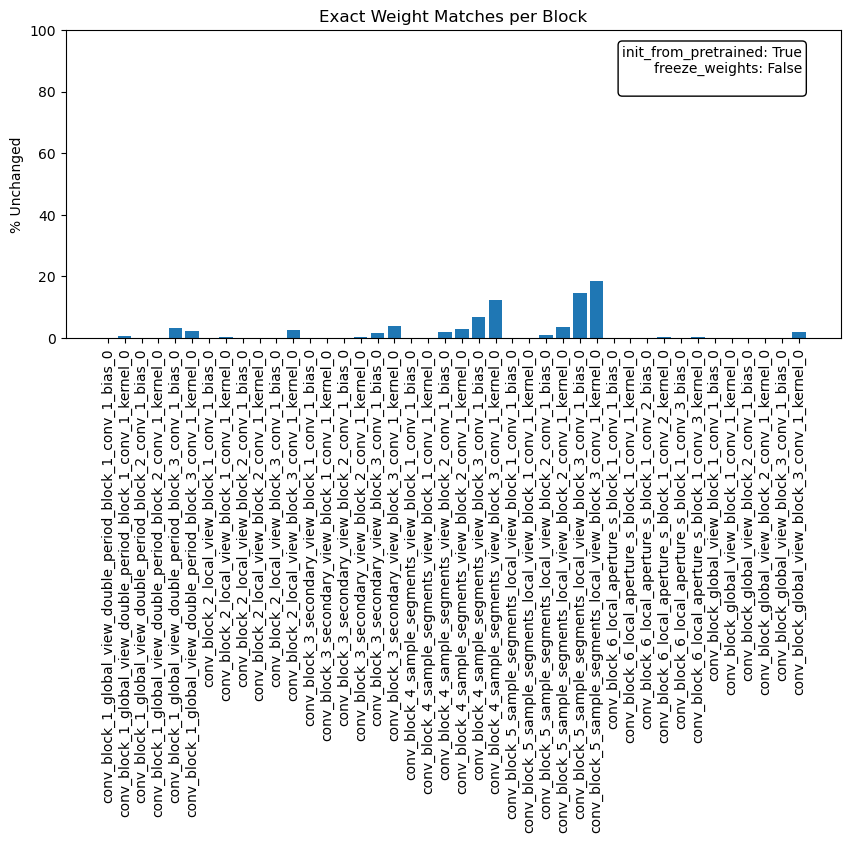

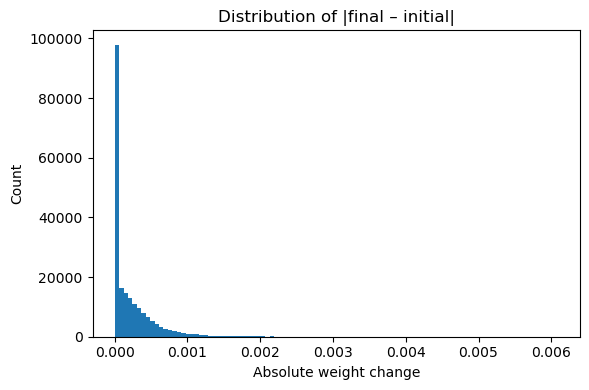

In [2]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import json

# time='180647'
# day,time='20250505','185210'
day,time='20250507','175635'
# day,time='20250507','180424'

# ─── CONFIG ───────────────────────────────────────────────────────────────────────
initial_path = (f"mnt/tess/models/vetting/{day}/cshallue/AstroCNNModelVetting_cshallue_{day}_{time}/initial_block_weights.npz")
final_path = (f"mnt/tess/models/vetting/{day}/cshallue/AstroCNNModelVetting_cshallue_{day}_{time}/final_block_weights.npz")

# ────────────────────────────────────────────────────────────────────────────────


config_path = (f"/pdo/users/pablomer/mnt/tess/models/vetting/{day}/cshallue/AstroCNNModelVetting_cshallue_{day}_{time}/config.json")

#"init_from_pretrained_model": true,
#"freeze_pretrained_params": false,
#
# Load the config
with open(config_path, "r") as f:
    config = json.load(f)
    init_from_pretrained = config.get("init_from_pretrained_model", None)
    freeze_weights = config.get("freeze_pretrained_params", None)


# Load both archives
init = np.load(initial_path)
fin  = np.load(final_path)




# Find the intersection of keys (blocks) present in both
blocks = sorted(set(init.files) & set(fin.files))

# … after loading init[...] and fin[...] …
matches_per_block = {}
total_per_block   = {}

# tolerances
rtol = 1e-5
atol = 1e-8

for blk in blocks:
    w0 = init[blk]
    w1 = fin[blk]
    total = w0.size
    mask = np.isclose(w0, w1, rtol=rtol, atol=atol) # |a-b| <= atol + rtol * |b|
    matches = np.sum(mask)
    matches_per_block[blk] = matches
    total_per_block[blk]   = total


# Print per-block counts
print("Per-block exact matches:")
for blk in blocks:
    m = matches_per_block[blk]
    t = total_per_block[blk]
    pct = m / t * 100
    print(f"  {blk:30s} : {m:8d} / {t:8d}  ({pct:5.2f}%)")

# Print overall
overall_matches = sum(matches_per_block.values())
overall_total   = sum(total_per_block.values())
print("\nOverall exact matches:")
print(f"  {overall_matches} / {overall_total}  "
      f"({overall_matches/overall_total*100:.2f}%)")

# ─── VISUALIZATION ───────────────────────────────────────────────────────────────

# 1) Bar chart of % unchanged per block
labels = blocks
percent_unchanged = [
    matches_per_block[b] / total_per_block[b] * 100 for b in labels
]

plt.figure(figsize=(10, 4))
plt.bar(labels, percent_unchanged)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("% Unchanged")
plt.title("Exact Weight Matches per Block")

#add a text box with the config values
config_text = (
    f"init_from_pretrained: {init_from_pretrained}\n"
    f"freeze_weights: {freeze_weights}\n"
)
plt.gca().text(
    0.95, 0.95, config_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))






plt.tight_layout()
plt.ylim(0, 100)
plt.show()

# 2) Histogram of absolute weight changes
#    (flatten diffs across all blocks)
all_diffs = np.concatenate([
    (fin[b] - init[b]).ravel() for b in blocks
])

plt.figure(figsize=(6, 4))
plt.hist(np.abs(all_diffs), bins=100)
plt.xlabel("Absolute weight change")
plt.ylabel("Count")
plt.title("Distribution of |final – initial|")
plt.tight_layout()
plt.show()


In [ ]:
# assume init = np.load(initial_path) is already done

# 1) total number of parameters in the init archive
total_params = sum(arr.size for arr in init.values())

# 2) how many of those live in your local_aperture_s conv weights vs the rest
roi_keys = [
    'conv_block_6_local_aperture_s_block_1_conv_1_kernel_0',
    'conv_block_6_local_aperture_s_block_1_conv_1_bias_0',
    'conv_block_6_local_aperture_s_block_1_conv_2_kernel_0',
    'conv_block_6_local_aperture_s_block_1_conv_2_bias_0',
    'conv_block_6_local_aperture_s_block_1_conv_3_kernel_0',
    'conv_block_6_local_aperture_s_block_1_conv_3_bias_0',
]
roi_params = sum(init[k].size for k in roi_keys)
other_params = total_params - roi_params

print(f"Total parameters model's convolutional blocks: {total_params:,}")
print(f" →   in local_aperture_s convs:    {roi_params:,}")
print(f" →   everywhere else:             {other_params:,}")
print("Apart from this, there is the weights from the pre-logits",'\n'," dense layers and the final output layer")


Total parameters model's convolutional blocks: 206,727
 →   in local_aperture_s convs:    2,848
 →   everywhere else:             203,879
Apart from this, there is the weights from the pre-logits 
  dense layers and the final output layer


In [51]:
init.files

['conv_block_global_view_block_1_conv_1_kernel_0',
 'conv_block_global_view_block_1_conv_1_bias_0',
 'conv_block_global_view_block_2_conv_1_kernel_0',
 'conv_block_global_view_block_2_conv_1_bias_0',
 'conv_block_global_view_block_3_conv_1_kernel_0',
 'conv_block_global_view_block_3_conv_1_bias_0',
 'conv_block_1_global_view_double_period_block_1_conv_1_kernel_0',
 'conv_block_1_global_view_double_period_block_1_conv_1_bias_0',
 'conv_block_1_global_view_double_period_block_2_conv_1_kernel_0',
 'conv_block_1_global_view_double_period_block_2_conv_1_bias_0',
 'conv_block_1_global_view_double_period_block_3_conv_1_kernel_0',
 'conv_block_1_global_view_double_period_block_3_conv_1_bias_0',
 'conv_block_2_local_view_block_1_conv_1_kernel_0',
 'conv_block_2_local_view_block_1_conv_1_bias_0',
 'conv_block_2_local_view_block_2_conv_1_kernel_0',
 'conv_block_2_local_view_block_2_conv_1_bias_0',
 'conv_block_2_local_view_block_3_conv_1_kernel_0',
 'conv_block_2_local_view_block_3_conv_1_bias_0'

In [52]:
old_keys = list(init.files)

# 2) Build rename map
rename_map = {}
for full_name in old_keys:
    parts = full_name.split('_')
    # find the 'block' that comes right before the block number
    # note: the first 'block' lives at parts[1], so we start our search at index=2
    block_pos = parts.index('block', 2)
    feature = '_'.join(parts[2:block_pos])
    block_idx = parts[block_pos + 1]
    # next 'conv' keyword tells us the conv-layer index
    conv_pos = parts.index('conv', block_pos + 2)
    conv_idx = parts[conv_pos + 1]
    # kind is 'kernel' or 'bias'
    kind = parts[-2]
    kind_abbr = 'k' if kind == 'kernel' else 'b'
    short_label = f"{feature}.b{block_idx}.c{conv_idx}.{kind_abbr}"
    rename_map[full_name] = short_label

# 3) Remap into a new dict
init_short = { rename_map[k]: init[k] for k in old_keys }

# 4) (Optional) inspect
print("New short labels:")
print(list(init_short.keys()))

# Now you can use `init_short` in place of `init` when computing your matches &
# plotting.  Your `blocks = sorted(init_short.keys())` will give you exactly the
# short labels you want on the x‐axis.

New short labels:
['global_view.b1.c1.k', 'global_view.b1.c1.b', 'global_view.b2.c1.k', 'global_view.b2.c1.b', 'global_view.b3.c1.k', 'global_view.b3.c1.b', '1_global_view_double_period.b1.c1.k', '1_global_view_double_period.b1.c1.b', '1_global_view_double_period.b2.c1.k', '1_global_view_double_period.b2.c1.b', '1_global_view_double_period.b3.c1.k', '1_global_view_double_period.b3.c1.b', '2_local_view.b1.c1.k', '2_local_view.b1.c1.b', '2_local_view.b2.c1.k', '2_local_view.b2.c1.b', '2_local_view.b3.c1.k', '2_local_view.b3.c1.b', '3_secondary_view.b1.c1.k', '3_secondary_view.b1.c1.b', '3_secondary_view.b2.c1.k', '3_secondary_view.b2.c1.b', '3_secondary_view.b3.c1.k', '3_secondary_view.b3.c1.b', '4_sample_segments_view.b1.c1.k', '4_sample_segments_view.b1.c1.b', '4_sample_segments_view.b2.c1.k', '4_sample_segments_view.b2.c1.b', '4_sample_segments_view.b3.c1.k', '4_sample_segments_view.b3.c1.b', '5_sample_segments_local_view.b1.c1.k', '5_sample_segments_local_view.b1.c1.b', '5_sample_seg

In [50]:
for block in init.files:
    # Print the block name
    print(f"Block: {block}")
    #Print the shape of the weights
    print(f"Shape: {init[block].shape}")
    # Print the first 5 weights
    print("First 5 weights:")
    print(init[block].flatten()[:5])

Block: conv_block_global_view_block_1_conv_1_kernel_0
Shape: (3, 6, 17)
First 5 weights:
[ 0.15497172  0.2191624   0.24825937  0.230268   -0.20821942]
Block: conv_block_global_view_block_1_conv_1_bias_0
Shape: (17,)
First 5 weights:
[0. 0. 0. 0. 0.]
Block: conv_block_global_view_block_2_conv_1_kernel_0
Shape: (3, 17, 34)
First 5 weights:
[-0.08014996  0.07873391  0.16419001 -0.06674065  0.133188  ]
Block: conv_block_global_view_block_2_conv_1_bias_0
Shape: (34,)
First 5 weights:
[0. 0. 0. 0. 0.]
Block: conv_block_global_view_block_3_conv_1_kernel_0
Shape: (3, 34, 68)
First 5 weights:
[0.02379008 0.06824481 0.10451972 0.04919431 0.13805895]
Block: conv_block_global_view_block_3_conv_1_bias_0
Shape: (68,)
First 5 weights:
[0. 0. 0. 0. 0.]
Block: conv_block_1_global_view_double_period_block_1_conv_1_kernel_0
Shape: (3, 3, 16)
First 5 weights:
[-0.2133081  -0.16126394  0.12824318 -0.14683872 -0.03154626]
Block: conv_block_1_global_view_double_period_block_1_conv_1_bias_0
Shape: (16,)
First

[False, False]


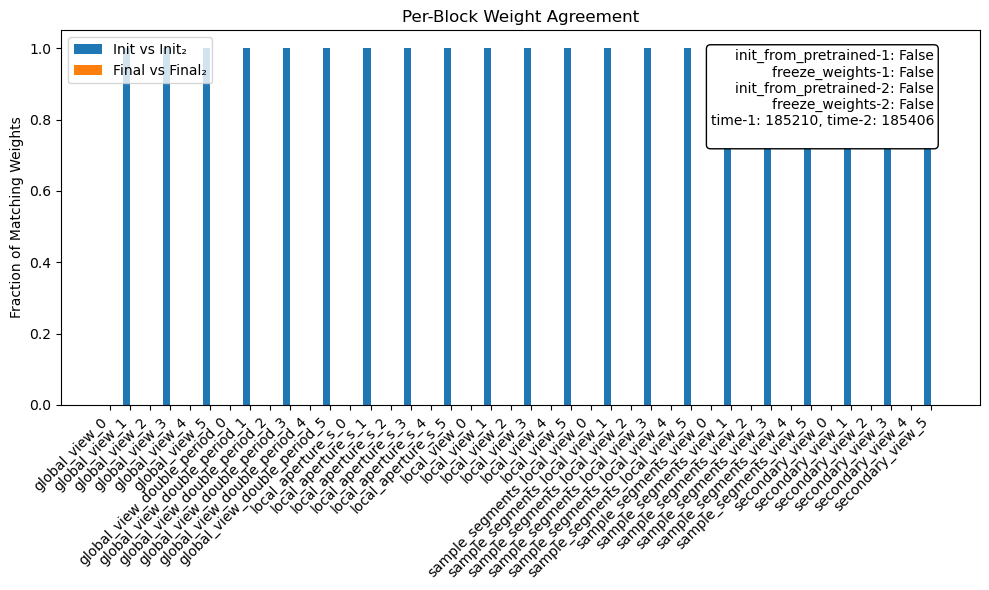

In [37]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import json

TF1='180647'
TF2='184345'
TT='182135'
FF1='185210'
FF2='185406'

time1=FF1
time2=FF2

# ─── CONFIG ───────────────────────────────────────────────────────────────────────
initial_path_1 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time1}/initial_block_weights.npz")
initial_path_2 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time2}/initial_block_weights.npz")

final_path_1 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time1}/final_block_weights.npz")
final_path_2 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time2}/final_block_weights.npz")
# ────────────────────────────────────────────────────────────────────────────────


config_path_1 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time1}/config.json")
config_path_2 = (f"/pdo/users/pablomer/mnt/tess/models/vetting/20250505/cshallue/AstroCNNModelVetting_cshallue_20250505_{time2}/config.json")

init_from_pretrained = [None, None]
freeze_weights = [None, None]
# Load the config
for i,config_path in enumerate([config_path_1, config_path_2]):
    with open(config_path, "r") as f:
        config = json.load(f)
        init_from_pretrained[i] = config.get("init_from_pretrained_model", None)
        freeze_weights[i] = config.get("freeze_pretrained_params", None)

print(init_from_pretrained)


# Load both archives
init1 = np.load(initial_path_1)
init2 = np.load(initial_path_2)

fin1  = np.load(final_path_1)
fin2  = np.load(final_path_2)

# Find the intersection of keys (blocks) present in both
blocks = sorted(set(init1.files) & set(fin1.files))

# … after loading init[...] and fin[...] …
matches_per_block_init = {}
total_per_block_init   = {}
matches_per_block_final = {}
total_per_block_final   = {}

# tolerances
rtol = 1e-5
atol = 1e-8

for blk in blocks:
    w0 = init1[blk]
    w1 = init2[blk]
    total = w0.size
    mask = np.isclose(w0, w1, rtol=rtol, atol=atol) # |a-b| <= atol + rtol * |b|
    matches = np.sum(mask)
    matches_per_block_init[blk] = matches
    total_per_block_init[blk]   = total

    w0 = fin1[blk]
    w1 = fin2[blk]
    total = w0.size
    mask = np.isclose(w0, w1, rtol=rtol, atol=atol) # |a-b| <= atol + rtol * |b|
    matches = np.sum(mask)
    matches_per_block_final[blk] = matches
    total_per_block_final[blk]   = total



# 1) compute fractions
frac_init  = [matches_per_block_init[blk]  / total_per_block_init[blk]  for blk in blocks]
frac_final = [matches_per_block_final[blk] / total_per_block_final[blk] for blk in blocks]

# 2) plot
x     = np.arange(len(blocks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, frac_init,  width, label='Init vs Init₂')
ax.bar(x + width/2, frac_final, width, label='Final vs Final₂')

# labels & legend
ax.set_xticks(x)
ax.set_xticklabels(blocks, rotation=45, ha='right')
ax.set_ylabel('Fraction of Matching Weights')
ax.set_title('Per-Block Weight Agreement')
ax.legend()

# Text box with config values
config_text = (
    f"init_from_pretrained-1: {init_from_pretrained[0]}\n"
    f"freeze_weights-1: {freeze_weights[0]}\n"
    f"init_from_pretrained-2: {init_from_pretrained[1]}\n"
    f"freeze_weights-2: {freeze_weights[1]}\n"
    f"time-1: {time1}, time-2: {time2}\n"
)
ax.text(
    0.95, 0.95, config_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))

plt.tight_layout()
plt.show()


---


In [ ]:
#!/usr/bin/env python3
import os
import numpy as np
import matplotlib.pyplot as plt
import json

# time='180647'
# day,time='20250505','185210'
# day,time='20250507','175635'
day,time='20250507','180424'

# ─── CONFIG ───────────────────────────────────────────────────────────────────────
initial_path = (f"mnt/tess/models/vetting/{day}/cshallue/AstroCNNModelVetting_cshallue_{day}_{time}/initial_block_weights.npz")
final_path = (f"mnt/tess/models/vetting/{day}/cshallue/AstroCNNModelVetting_cshallue_{day}_{time}/final_block_weights.npz")

# ────────────────────────────────────────────────────────────────────────────────


config_path = (f"/pdo/users/pablomer/mnt/tess/models/vetting/{day}/cshallue/AstroCNNModelVetting_cshallue_{day}_{time}/config.json")

#"init_from_pretrained_model": true,
#"freeze_pretrained_params": false,
#
# Load the config
with open(config_path, "r") as f:
    config = json.load(f)
    init_from_pretrained = config.get("init_from_pretrained_model", None)
    freeze_weights = config.get("freeze_pretrained_params", None)


# Load both archives
init = np.load(initial_path)
fin  = np.load(final_path)

old_keys = list(init.files)

# 2) Build rename map
rename_map = {}
for full_name in old_keys:
    parts = full_name.split('_')
    # find the 'block' that comes right before the block number
    # note: the first 'block' lives at parts[1], so we start our search at index=2
    block_pos = parts.index('block', 2)
    feature = '_'.join(parts[2:block_pos])
    block_idx = parts[block_pos + 1]
    # next 'conv' keyword tells us the conv-layer index
    conv_pos = parts.index('conv', block_pos + 2)
    conv_idx = parts[conv_pos + 1]
    # kind is 'kernel' or 'bias'
    kind = parts[-2]
    kind_abbr = 'k' if kind == 'kernel' else 'b'
    short_label = f"{feature}.b{block_idx}.c{conv_idx}.{kind_abbr}"
    rename_map[full_name] = short_label

# 3) Remap into a new dict
init_short = { rename_map[k]: init[k] for k in old_keys }
fin_short  = { rename_map[k]: fin[k] for k in old_keys }

init=init_short
fin=fin_short

# Find the intersection of keys (blocks) present in both
blocks = sorted(init.keys())

# … after loading init[...] and fin[...] …
matches_per_block = {}
total_per_block   = {}

# tolerances
rtol = 1e-5
atol = 1e-8

for blk in blocks:
    w0 = init[blk]
    w1 = fin[blk]
    total = w0.size
    mask = np.isclose(w0, w1, rtol=rtol, atol=atol) # |a-b| <= atol + rtol * |b|
    matches = np.sum(mask)
    matches_per_block[blk] = matches
    total_per_block[blk]   = total


# Print per-block counts
print("Per-block exact matches:")
for blk in blocks:
    m = matches_per_block[blk]
    t = total_per_block[blk]
    pct = m / t * 100
    print(f"  {blk:30s} : {m:8d} / {t:8d}  ({pct:5.2f}%)")

# Print overall
overall_matches = sum(matches_per_block.values())
overall_total   = sum(total_per_block.values())
print("\nOverall exact matches:")
print(f"  {overall_matches} / {overall_total}  "
      f"({overall_matches/overall_total*100:.2f}%)")

# ─── VISUALIZATION ───────────────────────────────────────────────────────────────

# 1) Bar chart of % unchanged per block
labels = blocks
percent_unchanged = [
    matches_per_block[b] / total_per_block[b] * 100 for b in labels
]

plt.figure(figsize=(10, 4))
plt.bar(labels, percent_unchanged)
plt.xticks(rotation=90, fontsize=10)
plt.ylabel("% Unchanged")
plt.title("Exact Weight Matches per Block")

#add a text box with the config values
config_text = (
    f"init_from_pretrained: {init_from_pretrained}\n"
    f"freeze_weights: {freeze_weights}\n"
)
plt.gca().text(
    0.95, 0.95, config_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor="black", facecolor="white"))






plt.tight_layout()
plt.ylim(0, 100)
plt.show()

# 2) Histogram of absolute weight changes
#    (flatten diffs across all blocks)
all_diffs = np.concatenate([
    (fin[b] - init[b]).ravel() for b in blocks
])

plt.figure(figsize=(6, 4))
plt.hist(np.abs(all_diffs), bins=100)
plt.xlabel("Absolute weight change")
plt.ylabel("Count")
plt.title("Distribution of |final – initial|")
plt.tight_layout()
plt.show()
